## **Exploratory Data Analysis**

In [79]:
#Importing the necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [80]:
data = yf.download("SPY", start = "2014-12-27", end = "2026-02-10")

[*********************100%***********************]  1 of 1 completed


In [81]:
data

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2014-12-29,172.849533,173.056568,172.369210,172.435463,79643900
2014-12-30,171.922058,172.559718,171.847516,172.427225,73540800
2014-12-31,170.216049,172.410630,170.091833,172.245004,130333800
2015-01-02,170.125000,171.325815,169.089824,170.911744,121465900
2015-01-05,167.052612,169.247181,166.746204,169.081555,169632600
...,...,...,...,...,...
2026-02-03,687.652039,695.061795,682.167018,694.313838,107904600
2026-02-04,684.321106,689.566790,679.903179,688.469749,105204600


Let's change the order so that open is the first column:

In [82]:
prices = data[["Open", "High", "Low", "Close", "Volume"]].copy()

In [83]:
prices

Price,Open,High,Low,Close,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2014-12-29,172.435463,173.056568,172.369210,172.849533,79643900
2014-12-30,172.427225,172.559718,171.847516,171.922058,73540800
2014-12-31,172.245004,172.410630,170.091833,170.216049,130333800
2015-01-02,170.911744,171.325815,169.089824,170.125000,121465900
2015-01-05,169.081555,169.247181,166.746204,167.052612,169632600
...,...,...,...,...,...
2026-02-03,694.313838,695.061795,682.167018,687.652039,107904600
2026-02-04,688.469749,689.566790,679.903179,684.321106,105204600


Create a returns column:

In [84]:
prices["return"] = prices["Close"].pct_change()

In [85]:
prices

Price,Open,High,Low,Close,Volume,return
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2014-12-29,172.435463,173.056568,172.369210,172.849533,79643900,NaN
2014-12-30,172.427225,172.559718,171.847516,171.922058,73540800,-0.005366
2014-12-31,172.245004,172.410630,170.091833,170.216049,130333800,-0.009923
2015-01-02,170.911744,171.325815,169.089824,170.125000,121465900,-0.000535
2015-01-05,169.081555,169.247181,166.746204,167.052612,169632600,-0.018060
...,...,...,...,...,...,...
2026-02-03,694.313838,695.061795,682.167018,687.652039,107904600,-0.008455
2026-02-04,688.469749,689.566790,679.903179,684.321106,105204600,-0.004844


We need to create our target variable which is volatility. Volatility in finance is commonly measured using standard deviation, so thats what we'll use.

**What exactly is standard deviation?**
- Standard deviation is a measure of how far off a figure/measurement is from the mean 
- It's the sqaure root of the variance 

**Very helpful. What's the variance?**
- Variance is the average of the sqaured differences from the mean.

So in short we calculate the mean, square the differences then find the average (variance) -> sqaure root that figure (standard deviation) 

We will create a rolling future volatility target:

In [86]:
prices["future_vol_5"] = (prices["return"].rolling(5).std().shift(-5))
prices["future_vol_10"] = (prices["return"].rolling(10).std().shift(-10))
prices["future_vol_20"] = (prices["return"].rolling(20).std().shift(-20))

#5 days, 10 days, 20 days.
#Works by taking the next n days after the current day to calculate the standard deviation for that day, then repeats for each day.

In [87]:
prices

Price,Open,High,Low,Close,Volume,return,future_vol_5,future_vol_10,future_vol_20
Ticker,SPY,SPY,SPY,SPY,SPY,,,,
Date,,,,,,,,,
2014-12-29,172.435463,173.056568,172.369210,172.849533,79643900,NaN,0.006469,0.010777,0.010208
2014-12-30,172.427225,172.559718,171.847516,171.922058,73540800,-0.005366,0.011609,0.010794,0.010477
2014-12-31,172.245004,172.410630,170.091833,170.216049,130333800,-0.009923,0.014869,0.010744,0.010608
2015-01-02,170.911744,171.325815,169.089824,170.125000,121465900,-0.000535,0.015359,0.011918,0.011050
2015-01-05,169.081555,169.247181,166.746204,167.052612,169632600,-0.018060,0.013034,0.010482,0.010767
...,...,...,...,...,...,...,...,...,...
2026-02-03,694.313838,695.061795,682.167018,687.652039,107904600,-0.008455,NaN,NaN,NaN
2026-02-04,688.469749,689.566790,679.903179,684.321106,105204600,-0.004844,NaN,NaN,NaN


In [88]:
prices = prices[
    (prices.index >= "2015-01-01") &
    (prices.index <= "2025-12-31")
]

In [89]:
prices

Price,Open,High,Low,Close,Volume,return,future_vol_5,future_vol_10,future_vol_20
Ticker,SPY,SPY,SPY,SPY,SPY,,,,
Date,,,,,,,,,
2015-01-02,170.911744,171.325815,169.089824,170.125000,121465900,-0.000535,0.015359,0.011918,0.011050
2015-01-05,169.081555,169.247181,166.746204,167.052612,169632600,-0.018060,0.013034,0.010482,0.010767
2015-01-06,167.359012,167.880745,164.684120,165.479141,209151400,-0.009419,0.012010,0.009991,0.010557
2015-01-07,166.804184,167.880770,166.356994,167.541229,125346700,0.012461,0.010899,0.010304,0.010435
2015-01-08,168.948990,170.729500,168.932436,170.514175,147217800,0.017745,0.002479,0.008853,0.009682
...,...,...,...,...,...,...,...,...,...
2025-12-24,686.076320,688.948481,685.926705,688.499695,39445600,0.003518,0.003555,0.004754,0.006669
2025-12-26,688.758989,689.776169,687.392725,688.429871,41613300,-0.000101,0.005340,0.004758,0.006722


Now we have data from the start of 2015 to the end of 2025 including returns and the rolling future volatility 

In [90]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Open, SPY)        2766 non-null   float64
 1   (High, SPY)        2766 non-null   float64
 2   (Low, SPY)         2766 non-null   float64
 3   (Close, SPY)       2766 non-null   float64
 4   (Volume, SPY)      2766 non-null   int64  
 5   (return, )         2766 non-null   float64
 6   (future_vol_5, )   2766 non-null   float64
 7   (future_vol_10, )  2766 non-null   float64
 8   (future_vol_20, )  2766 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 216.1 KB


In [91]:
prices.duplicated().any()

np.False_

Since we don't have any missing or duplicated values, we can pretty much skip imputation, dropping rows and dropping duplicate rows.

In [92]:
prices.describe()

Price,Open,High,Low,Close,Volume,return,future_vol_5,future_vol_10,future_vol_20
Ticker,SPY,SPY,SPY,SPY,SPY,,,,
count,2766.000000,2766.000000,2766.000000,2766.000000,2.766000e+03,2766.000000,2766.000000,2766.000000,2766.000000
mean,336.953986,338.776494,334.960358,337.010644,8.608106e+07,0.000564,0.008783,0.009115,0.009361
std,140.331270,140.995278,139.561325,140.346877,4.392519e+07,0.011206,0.007312,0.006728,0.006266
min,154.119223,155.606836,152.465257,154.558746,2.027000e+07,-0.109423,0.000426,0.001265,0.002010
25%,218.596412,219.318694,217.486253,218.913712,5.874842e+07,-0.003702,0.004482,0.005149,0.005711
50%,299.490743,301.717764,298.196428,299.900528,7.570780e+07,0.000634,0.007098,0.007501,0.007668
75%,422.296731,424.131742,419.850016,421.967537,9.941975e+07,0.005923,0.010869,0.011182,0.011475
max,688.758989,689.776169,687.392725,688.499695,5.072443e+08,0.105019,0.088334,0.070733,0.058701


It's very interesting to see how tightly packed the numbers actually are, given that the data is over eleven-ish years. For example I was not expecting the mean of all values to be so close together (it was unexpected for me at least).

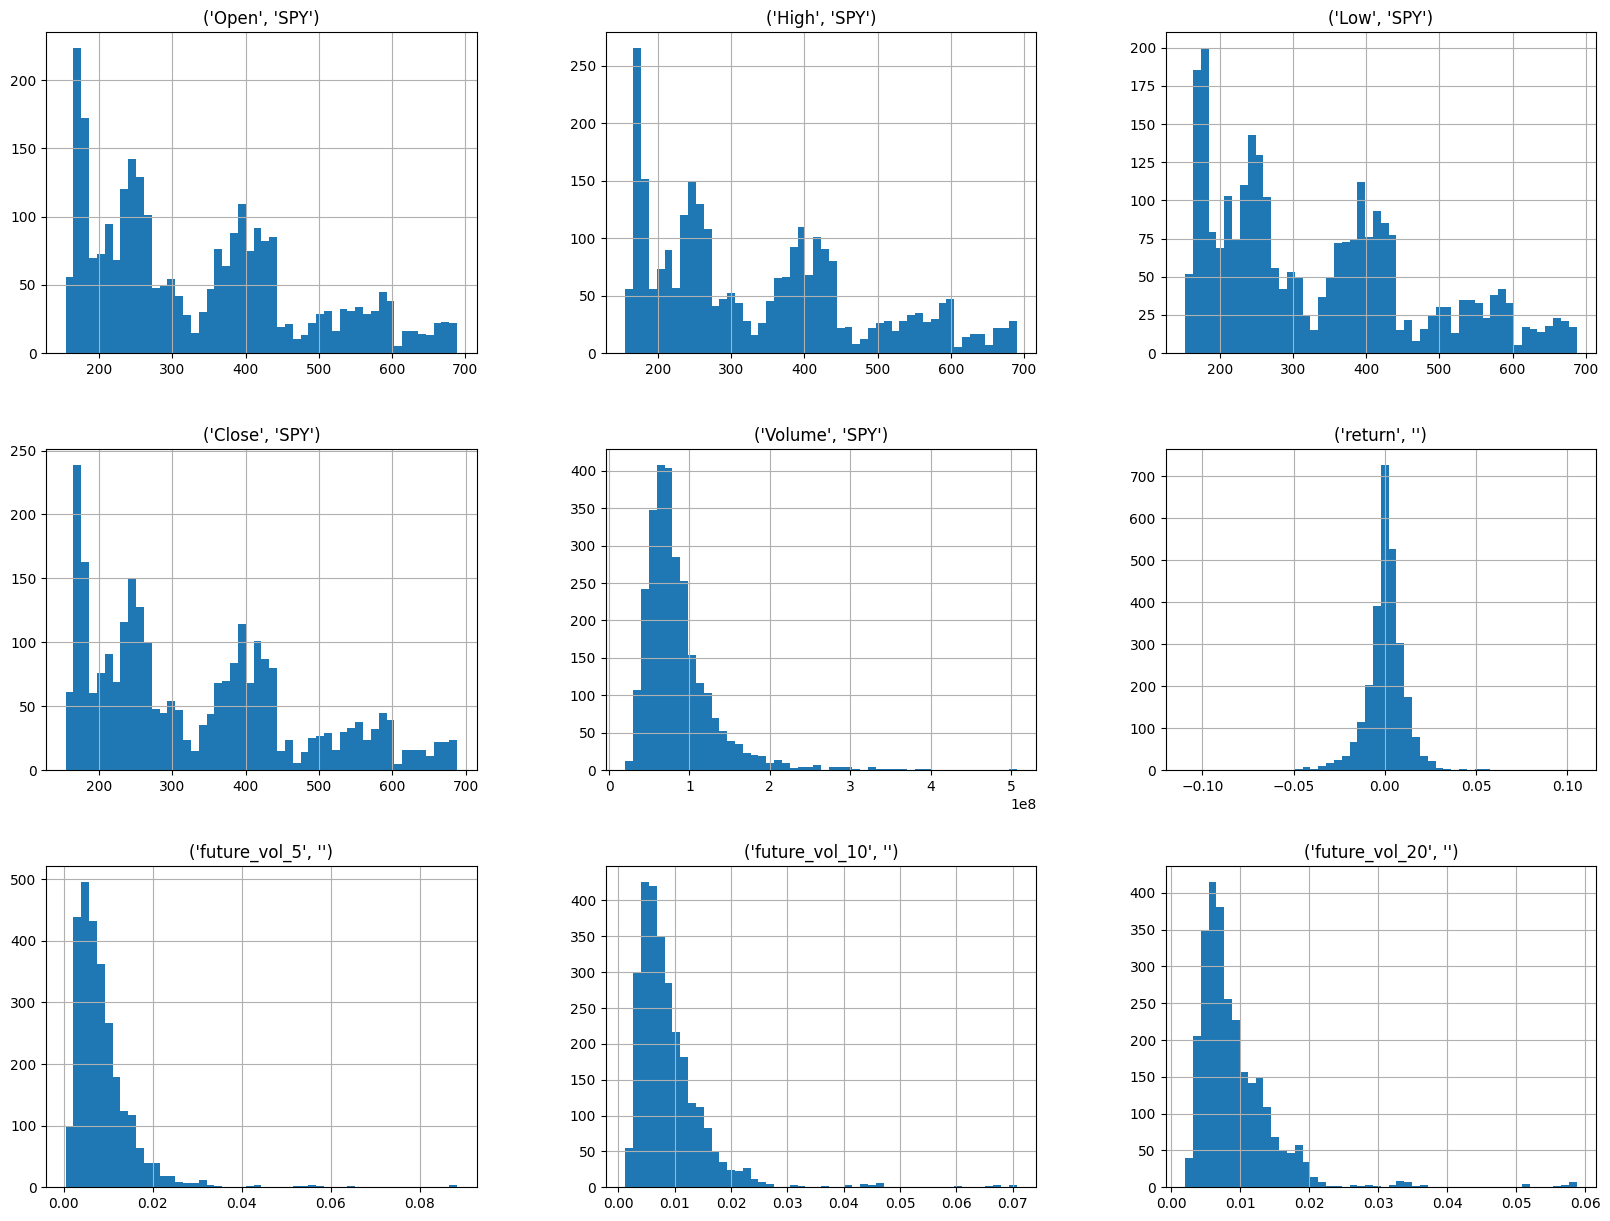

In [93]:
prices.hist(bins = 50, figsize=(20,15))
plt.show()

We can clearly see across "Open", "High", "Low", "Close" there are more prices below 450 than above, indicating that for a larger portion of the eleven odd years, these prices were more common, and it's likely that the more expensive prices are more recent. The histograms are also very similar in shape.  

We see that most of the returns are small (in either direction) with most grouping near zero.

The future volatility histograms are all positively skewed with them becoming very slightly negatively skewed as the number of days becomes larger.

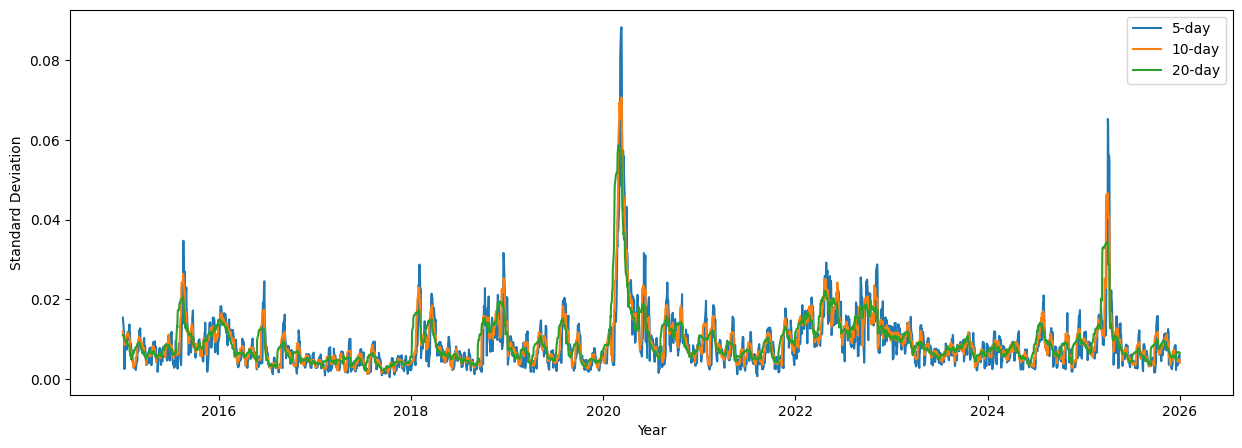

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(prices.index, prices["future_vol_5"], label="5-day")
plt.plot(prices.index, prices["future_vol_10"], label="10-day")
plt.plot(prices.index, prices["future_vol_20"], label="20-day")
plt.xlabel("Year")
plt.ylabel("Standard Deviation")
plt.legend()

We see that the 20 day rolling volatility plot is a lot "smoother" compared to the 10 day and five day plots. It's also interesting to see things were very volatile when COVID hit, but theres also a very big spike just after 2025 which could be related to advances and increase interest in AI.   